# 02 — Analysis

Construct features from the imbalance and order-book data, and determine which carry
information about `y_bps`. Input: `data/clean.parquet`. Output: `data/features.parquet`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

DATA = Path("data")
df = pd.read_parquet(DATA / "clean.parquet")
print(f"{len(df):,} rows | {df['date'].nunique()} days | {df['symbol'].nunique()} symbols")
df.head(3)

3,445,083 rows | 21 days | 560 symbols


,ts,date,symbol,secs_to_close,bid,ask,bid_qty,ask_qty,mid,side,shares,paired_shares,ref_price,near_price,far_price,adv,open,cross,y_bps
0,2025-03-03 15:50:00.000385287-05:00,2025-03-03 00:00:00-05:00,TSLQ,599.999615,47.60,47.69,100.0,100.0,47.645,BUY,1695.0,260.0,47.68,NaN,NaN,9644.652,41.76,46.53,-234.022458
1,2025-03-03 15:50:00.000611455-05:00,2025-03-03 00:00:00-05:00,VTRS,599.999389,9.33,9.34,3930.0,2900.0,9.335,BUY,2838.0,760635.0,9.34,NaN,NaN,11416.429,9.29,9.33,-5.356186
2,2025-03-03 15:50:00.000842662-05:00,2025-03-03 00:00:00-05:00,MNST,599.999157,55.15,55.16,20.0,498.0,55.155,BUY,153252.0,595352.0,55.16,NaN,NaN,6302.992,54.39,55.17,2.719608


## Feature design

Two normalisations run through everything: prices in **basis points relative to the
current mid**, since the universe spans $1 to $5,000; sizes as a **fraction of ADV**,
since 100,000 shares is a rounding error in AAPL and an enormous imbalance in a
microcap. (`adv` is in thousands of shares.)

`near_price` and `far_price` are heavy-tailed — before enough auction orders arrive
they can legitimately clear far from the continuous mid. The cell after the builder
shows those extreme rows are *more* correlated with the target, not less, so instead
of clipping them they get a signed log, `sign(x)·log(1+|x|)`, which compresses the
tail while preserving sign and ordering.

`side` takes four values: `BUY`/`SELL` map to ±1, `NONE` and `INSUFFICIENT` to 0.

In [2]:
BPS = 1e4

def slog(s):
    """Signed log — compresses fat tails while preserving order and sign."""
    return np.sign(s) * np.log1p(np.abs(s))


def build_features(df):
    out = df.sort_values(["symbol", "date", "ts"]).copy()
    mid = out["mid"]
    adv_shares = out["adv"] * 1_000.0          # adv is in thousands of shares

    # --- indicative prices, in bps vs mid ---------------------------------
    for col in ["ref_price", "near_price", "far_price"]:
        out[f"{col}_bps"] = BPS * (out[col] / mid - 1.0)
    out["near_far_bps"] = BPS * (out["near_price"] / out["far_price"] - 1.0)

    for c in ["near_price_bps", "far_price_bps", "near_far_bps"]:
        out[f"{c[:-4]}_slog"] = slog(out[c])

    # --- market state ------------------------------------------------------
    out["spread_bps"] = BPS * (out["ask"] - out["bid"]) / mid
    out["ret_open_slog"] = slog(BPS * (mid / out["open"] - 1.0))

    # --- imbalance ---------------------------------------------------------
    sgn = out["side"].astype(str).map({"BUY": 1.0, "SELL": -1.0}).fillna(0.0)
    out["imb_signed"] = out["shares"].fillna(0.0) * sgn
    out["imb_adv"] = out["imb_signed"] / adv_shares
    out["paired_adv"] = out["paired_shares"] / adv_shares
    denom = (out["imb_signed"].abs() + out["paired_shares"]).replace(0, np.nan)
    out["imb_ratio"] = out["imb_signed"] / denom            # scale-free, -1..1
    out["log_adv"] = np.log1p(adv_shares)

    # --- continuous order book --------------------------------------------
    qsum = (out["bid_qty"] + out["ask_qty"]).replace(0, np.nan)
    out["book_imb"] = (out["bid_qty"] - out["ask_qty"]) / qsum

    # --- time --------------------------------------------------------------
    out["t"] = out["secs_to_close"]
    out["post_355"] = (out["t"] <= 300).astype("int8")
    out["urgency"] = 1.0 - out["t"] / 600.0

    # --- dynamics: per-second rate, since the message cadence changes ------
    g = out.groupby(["symbol", "date"], observed=True)
    dt = (-g["secs_to_close"].diff()).replace(0, np.nan)
    out["d_imb_adv"] = g["imb_adv"].diff() / dt

    # --- interactions: the same imbalance means more at 15:59 than 15:50 ---
    for col in ["imb_ratio", "near_price_slog"]:
        out[f"{col}_x_urg"] = out[col] * out["urgency"]

    return out


feat = build_features(df)

FEATURES = [
    "ref_price_bps", "near_price_slog", "far_price_slog", "near_far_slog",
    "spread_bps", "ret_open_slog",
    "imb_adv", "imb_ratio", "paired_adv", "log_adv",
    "book_imb",
    "t", "post_355",
    "d_imb_adv",
    "imb_ratio_x_urg", "near_price_slog_x_urg",
]
print(f"{len(FEATURES)} features on {len(feat):,} rows")

16 features on 3,445,083 rows


In [3]:
# nulls should sit only where near/far do not exist yet (pre-15:55)
null = feat[FEATURES].isna().mean()
print(null[null > 0.01].round(4).sort_values(ascending=False).to_string())
print("\ninfinite:", int(np.isinf(feat[FEATURES].to_numpy(dtype="float64")).sum()),
      "| constant:", [c for c in FEATURES if feat[c].nunique() < 2])

# why signed-log rather than clip: the extreme rows are the informative ones
ext = feat["far_price_bps"].abs() > 500
print(f"\n|far_price_bps| > 500: {ext.mean():.2%} of rows, {feat.loc[ext, 'symbol'].nunique()} symbols")
print(f"  corr(far_bps, y) there: {feat.loc[ext, 'far_price_bps'].corr(feat.loc[ext, 'y_bps']):+.3f}")
print(f"  corr(far_bps, y) for |far| < 50: "
      f"{feat.loc[feat['far_price_bps'].abs() < 50, 'far_price_bps'].corr(feat.loc[feat['far_price_bps'].abs() < 50, 'y_bps']):+.3f}")

far_price_slog           0.1229
near_far_slog            0.1229
near_price_slog          0.0909
near_price_slog_x_urg    0.0909

infinite: 0 | constant: []

|far_price_bps| > 500: 3.32% of rows, 470 symbols
  corr(far_bps, y) there: +0.180
  corr(far_bps, y) for |far| < 50: +0.138


In [4]:
corr = pd.DataFrame({
    "pre_355": feat.loc[feat["post_355"] == 0, FEATURES + ["y_bps"]].corr()["y_bps"],
    "post_355": feat.loc[feat["post_355"] == 1, FEATURES + ["y_bps"]].corr()["y_bps"],
}).drop("y_bps")
corr.reindex(corr["post_355"].abs().sort_values(ascending=False).index).round(3)

,pre_355,post_355
ref_price_bps,0.106,0.312
imb_ratio_x_urg,0.083,0.195
imb_ratio,0.098,0.189
near_price_slog_x_urg,NaN,0.163
near_price_slog,NaN,0.149
far_price_slog,NaN,0.131
near_far_slog,NaN,-0.094
t,-0.034,-0.076
imb_adv,-0.011,0.067
ret_open_slog,-0.027,-0.065


In [5]:
key = ["ref_price_bps", "near_price_slog", "far_price_slog", "near_far_slog",
       "imb_adv", "imb_ratio", "book_imb", "paired_adv"]
bucket = pd.cut(feat["t"], [0, 60, 120, 300, 600], labels=["<1m", "1-2m", "2-5m", "5-10m"])
feat.groupby(bucket, observed=True).apply(lambda g: g[key].corrwith(g["y_bps"])).round(3)

,ref_price_bps,near_price_slog,far_price_slog,near_far_slog,imb_adv,imb_ratio,book_imb,paired_adv
t,,,,,,,,
<1m,0.476,0.358,0.355,-0.253,0.125,0.326,0.034,-0.010
1-2m,0.382,0.256,0.246,-0.183,0.088,0.236,0.026,0.001
2-5m,0.278,0.118,0.092,-0.070,0.057,0.166,0.019,0.011
5-10m,0.106,NaN,NaN,NaN,-0.011,0.098,0.008,-0.002


In [6]:
def zero_r2(y, yhat):
    """R^2 against predicting zero — the honest benchmark for a return."""
    return 1 - np.sum((y - yhat) ** 2) / np.sum(y ** 2)


b = feat[feat["post_355"] == 1].dropna(subset=["near_price_bps", "ref_price_bps"])
y = b["y_bps"].to_numpy()

print(f"n = {len(b):,}   std(y) = {y.std():.2f} bps\n")
print(pd.Series({
    "zero": zero_r2(y, np.zeros_like(y)),
    "near_price raw": zero_r2(y, b["near_price_bps"].to_numpy()),
    "ref_price raw": zero_r2(y, b["ref_price_bps"].to_numpy()),
}).round(4).to_string())

n = 3,131,880   std(y) = 22.09 bps

zero               0.0000
near_price raw   -54.6657
ref_price raw      0.0941


## What predicts the closing cross

**`ref_price` dominates.** Correlation with `y_bps` reaches 0.476 inside the final
minute, above `near_price` at 0.358, and unlike near/far it is published from 15:50
rather than 15:55. The reason is structural: `ref_price` is constrained to lie within
the BBO, so it cannot take the extreme values that make near/far unstable.

**Signal strength scales with proximity to the close.** Every indicative-price
correlation roughly quadruples from the 5–10 minute bucket to the final minute
(`ref_price`: 0.106 → 0.476). Before 15:55 only `ref_price` and `imb_ratio` carry
usable information at all.

**Imbalance matters as a ratio, not a raw size.** `imb_ratio` — leftover shares
relative to total auction interest — correlates 0.326 in the final minute against
0.125 for `imb_adv`. Scaling by same-day auction participation beats scaling by a
trailing 20-day average.

**`near_price` is directionally useful but badly scaled.** Used as a direct prediction
it scores −54.7, far worse than predicting no move, because its tail vastly overstates
the expected move. Only after signed-log compression does it contribute.

**The order book adds little.** `book_imb` peaks at 0.034 correlation, and `paired_adv`
and `d_imb_adv` are indistinguishable from zero. They are kept so the model can reject
them rather than being excluded by assumption.

### Baseline to beat

On post-15:55 rows, scored as R² against a zero prediction:

| Prediction | zero-R² |
|---|---|
| zero (no move) | 0.0000 |
| `near_price` raw | −54.67 |
| **`ref_price` raw** | **0.0941** |

`ref_price` raw is the bar. It requires no fitting, and any model that fails to clear
it has added nothing to what the exchange already publishes for free.

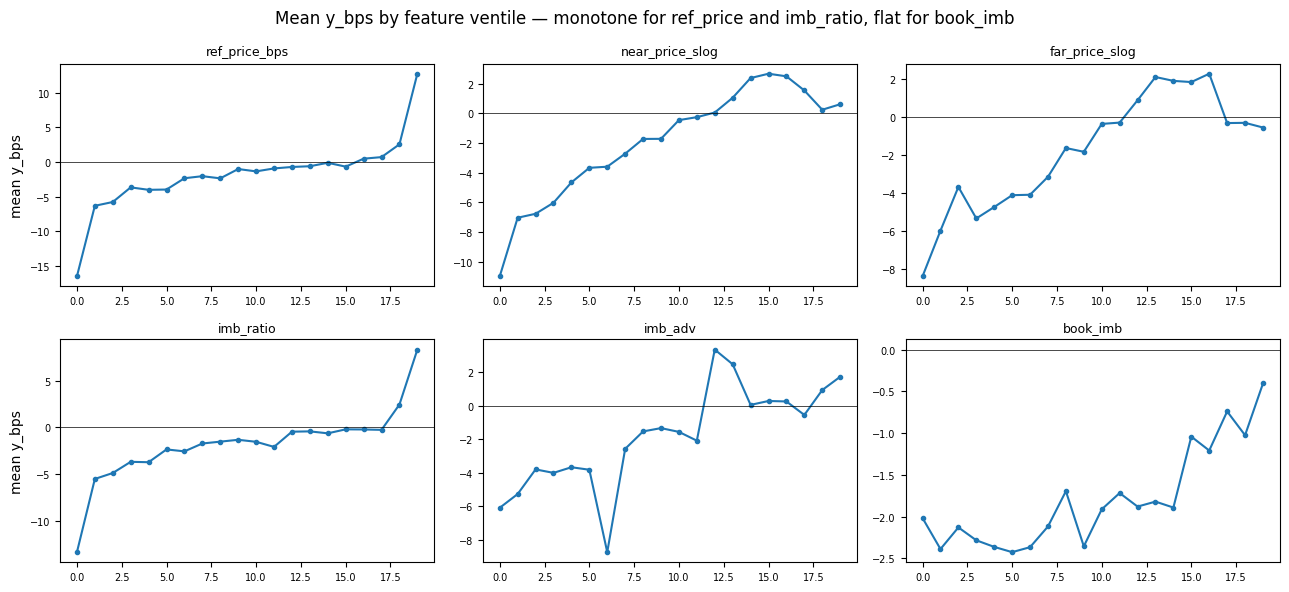

In [7]:
s = feat.sample(300_000, random_state=0)
show = ["ref_price_bps", "near_price_slog", "far_price_slog",
        "imb_ratio", "imb_adv", "book_imb"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.ravel(), show):
    d = s[[c, "y_bps"]].replace([np.inf, -np.inf], np.nan).dropna()
    b = pd.qcut(d[c].rank(method="first"), 20, labels=False)
    ax.plot(d.groupby(b)["y_bps"].mean().values, marker="o", ms=3)
    ax.axhline(0, lw=.5, color="k")
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
axes[0, 0].set_ylabel("mean y_bps"); axes[1, 0].set_ylabel("mean y_bps")
fig.suptitle("Mean y_bps by feature ventile — monotone for ref_price and imb_ratio, flat for book_imb")
plt.tight_layout()

In [8]:
keep = list(dict.fromkeys(
    ["ts", "date", "symbol", "y_bps", "mid", "cross",
     "near_price_bps", "ref_price_bps", "far_price_bps"] + FEATURES
))
out = feat[keep].copy()

floats = out.select_dtypes("float64").columns
out[floats] = out[floats].astype("float32")

out.to_parquet(DATA / "features.parquet", index=False)
print(f"wrote {out.shape[0]:,} x {out.shape[1]} | "
      f"{(DATA / 'features.parquet').stat().st_size / 1e6:.0f} MB")

wrote 3,445,083 x 24 | 166 MB
